# Assignment 2 – Task 2: Heart Disease Prediction System
---
**Deployment Link:** [https://heart-disease-predictor-ml.streamlit.app/](https://heart-disease-predictor-ml.streamlit.app/)

This notebook follows the **exact same steps** as Task 1 (Titanic Prediction):
1. Data Collection
2. Data Understanding (EDA)
3. Data Pre-processing & Label Encoding
4. Model Training (SVC)
5. Model Evaluation
6. Making Predictions
7. Saving the Trained Model

**Dataset:** UCI Heart Disease (Cleveland) – `heart.csv`  
**Algorithm:** Support Vector Classifier (SVC)  
**Constraint:** Only 4 input attributes selected from the dataset

### Selected 4 Input Attributes:
| Feature | Description |
|---------|-------------|
| `age` | Age of the patient (years) |
| `thalach` | Maximum heart rate achieved |
| `chol` | Serum cholesterol (mg/dl) |
| `cp` | Chest pain type (0-3) |


## Step 0 – Import Libraries

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
warnings.filterwarnings("ignore")
print("Libraries imported successfully OK")

Libraries imported successfully OK


## Step 1 – Data Collection
Load the Heart Disease dataset from the local CSV file.

In [2]:
df = pd.read_csv("heart.csv")
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Dataset Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


## Step 2 – Data Understanding (EDA)

In [3]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
print("=== Descriptive Statistics ===")
df.describe()

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print("=== Missing Values ===")
df.isnull().sum()

=== Missing Values ===


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Target Distribution (0=No Disease, 1=Disease) ===
target
1    526
0    499
Name: count, dtype: int64


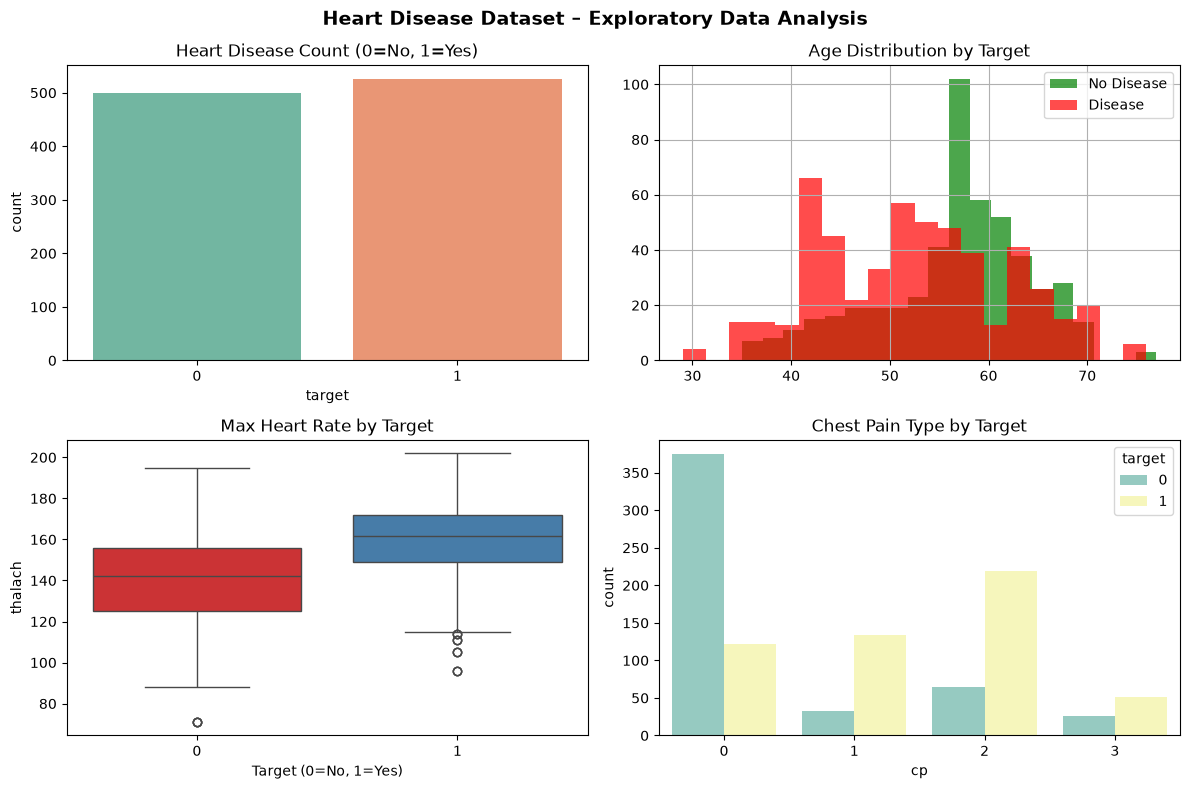

EDA plots saved OK


In [6]:
print("=== Target Distribution (0=No Disease, 1=Disease) ===")
print(df["target"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Heart Disease Dataset – Exploratory Data Analysis", fontsize=14, fontweight="bold")

sns.countplot(data=df, x="target", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Heart Disease Count (0=No, 1=Yes)")

df[df["target"]==0]["age"].hist(bins=20, ax=axes[0,1], alpha=0.7, color="green", label="No Disease")
df[df["target"]==1]["age"].hist(bins=20, ax=axes[0,1], alpha=0.7, color="red", label="Disease")
axes[0,1].set_title("Age Distribution by Target")
axes[0,1].legend()

sns.boxplot(data=df, x="target", y="thalach", ax=axes[1,0], palette="Set1")
axes[1,0].set_title("Max Heart Rate by Target")
axes[1,0].set_xlabel("Target (0=No, 1=Yes)")

sns.countplot(data=df, x="cp", hue="target", ax=axes[1,1], palette="Set3")
axes[1,1].set_title("Chest Pain Type by Target")

plt.tight_layout()
plt.savefig("heart_disease_eda.png", dpi=100)
plt.show()
print("EDA plots saved OK")

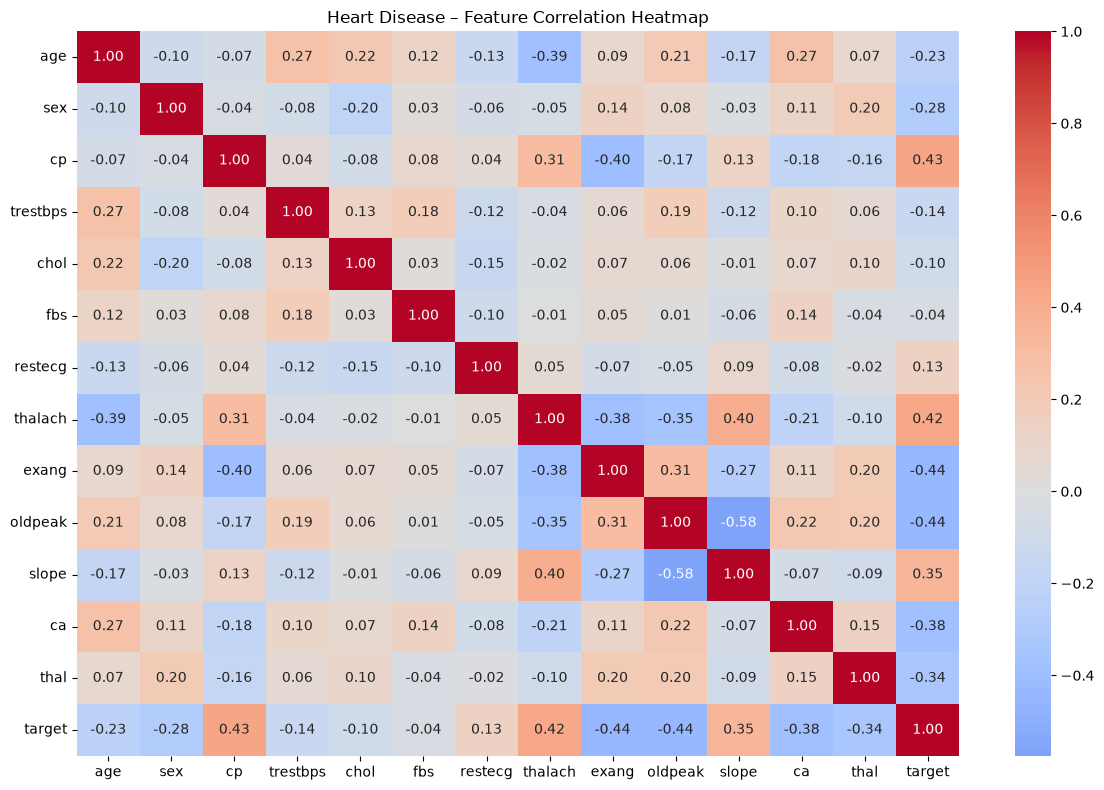

Correlation heatmap saved OK


In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heart Disease – Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("heart_disease_correlation.png", dpi=100)
plt.show()
print("Correlation heatmap saved OK")

## Step 3 – Data Pre-processing & Label Encoding

### ⚠️ Constraint: Select only 4 input attributes
Selected features: **age**, **thalach**, **chol**, **cp**

In [8]:
# === SELECTED 4 FEATURES (Assignment Constraint) ===
SELECTED_FEATURES = ["age", "thalach", "chol", "cp"]
TARGET = "target"

print(f"Selected features: {SELECTED_FEATURES}")
print(f"Target: {TARGET}\n")

df_model = df[SELECTED_FEATURES + [TARGET]].copy()

# Handle missing values
print(f"Missing values:\n{df_model.isnull().sum()}")
df_model.dropna(inplace=True)
print(f"\nShape after handling nulls: {df_model.shape}")

# Label Encoding for chest pain type (cp)
le_cp = LabelEncoder()
df_model["cp"] = le_cp.fit_transform(df_model["cp"])
print(f"\nLabel Encoder classes for cp: {le_cp.classes_}")

# Save encoded dataset
df_model.to_csv("heart_disease_encoded.csv", index=False)
print("Encoded dataset saved to heart_disease_encoded.csv OK")
df_model.head()

Selected features: ['age', 'thalach', 'chol', 'cp']
Target: target

Missing values:
age        0
thalach    0
chol       0
cp         0
target     0
dtype: int64

Shape after handling nulls: (1025, 5)



Label Encoder classes for cp: [0 1 2 3]


Encoded dataset saved to heart_disease_encoded.csv OK


,age,thalach,chol,cp,target
0,52,168,212,0,0
1,53,155,203,0,0
2,70,125,174,0,0
3,61,161,203,0,0
4,62,106,294,0,0


## Step 4 – Model Training (Support Vector Classifier)

In [9]:
X = df_model[SELECTED_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

svc_heart = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc_heart.fit(X_train, y_train)
print("\nSVC model trained successfully OK")

Training samples : 820
Testing  samples : 205

SVC model trained successfully OK


## Step 5 – Model Evaluation

Accuracy: 65.85%

Confusion Matrix:
[[62 40]
 [30 73]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.67      0.61      0.64       102
     Disease       0.65      0.71      0.68       103

    accuracy                           0.66       205
   macro avg       0.66      0.66      0.66       205
weighted avg       0.66      0.66      0.66       205



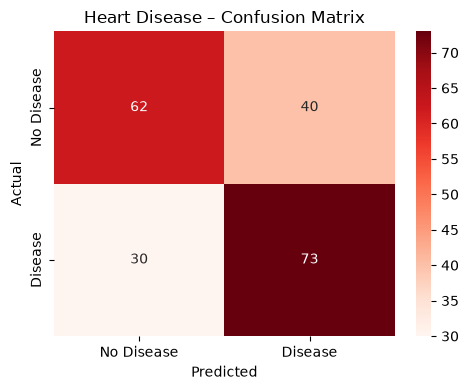

In [10]:
y_pred = svc_heart.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
cm     = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease","Disease"]))

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Heart Disease – Confusion Matrix")
plt.tight_layout()
plt.savefig("heart_disease_confusion_matrix.png", dpi=100)
plt.show()

## Step 6 – Making Predictions on Sample Data

In [11]:
sample_data = pd.DataFrame({
    "age":     [52,   67,   45,   38,   60],
    "thalach": [168,  108,  150,  170,  120],
    "chol":    [212,  300,  225,  174,  280],
    "cp":      [0,    1,    2,    3,    0],
})
sample_encoded = sample_data.copy()
sample_encoded["cp"] = le_cp.transform(sample_encoded["cp"])

predictions = svc_heart.predict(sample_encoded)
sample_data["Predicted"] = ["❤️ Heart Disease" if p==1 else "✅ No Heart Disease"
                              for p in predictions]

# Save predictions
sample_data.to_csv("heart_disease_predictions.csv", index=False)
print("Predictions saved to heart_disease_predictions.csv OK")
sample_data

Predictions saved to heart_disease_predictions.csv OK


,age,thalach,chol,cp,Predicted
0,52,168,212,0,❤️ Heart Disease
1,67,108,300,1,✅ No Heart Disease
2,45,150,225,2,❤️ Heart Disease
3,38,170,174,3,❤️ Heart Disease
4,60,120,280,0,✅ No Heart Disease


## Step 7 – Save Trained Model

In [12]:
# Save the SVC model
with open("heart_disease_svc_model.pkl", "wb") as f:
    pickle.dump(svc_heart, f)

# Save the LabelEncoder for 'cp'
with open("heart_disease_le_cp.pkl", "wb") as f:
    pickle.dump(le_cp, f)

print("Model saved to heart_disease_svc_model.pkl OK")
print("Label encoder saved to heart_disease_le_cp.pkl OK")
print("\n" + "="*50)
print("TASK 2 COMPLETE")
print("="*50)

Model saved to heart_disease_svc_model.pkl OK
Label encoder saved to heart_disease_le_cp.pkl OK

TASK 2 COMPLETE
